# Low-light enhancement training

A reproducible attention U-Net training workflow for paired low-light and normal-light images.
Run every cell in order after attaching the LOL and LOL-v2 Kaggle datasets.


In [1]:
# Standard library imports.
import json
import random
from collections import defaultdict
from dataclasses import asdict, dataclass
from pathlib import Path

# Third-party imports.
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers


In [2]:
@dataclass(frozen=True)
class Config:
    # Reproducibility and image preprocessing.
    seed: int = 42
    image_size: int = 384
    resize_size: int = 416  # Leaves room for a random 384×384 training crop.

    # Training hyperparameters.
    batch_size: int = 4
    base_filters: int = 48
    learning_rate: float = 1e-3
    epochs: int = 80
    validation_fraction: float = 0.10

    # Kaggle input/output paths. Dataset roots are detected automatically.
    input_dir: str = "/kaggle/input"
    output_dir: str = "/kaggle/working/denoisex"


CFG = Config()
OUTPUT_DIR = Path(CFG.output_dir)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
print(json.dumps(asdict(CFG), indent=2))


{
  "seed": 42,
  "image_size": 384,
  "resize_size": 416,
  "batch_size": 4,
  "base_filters": 48,
  "learning_rate": 0.001,
  "epochs": 80,
  "validation_fraction": 0.1,
  "input_dir": "/kaggle/input",
  "output_dir": "/kaggle/working/denoisex"
}


In [3]:
# Seed Python, NumPy, and TensorFlow before any shuffle or model construction.
random.seed(CFG.seed)
np.random.seed(CFG.seed)
tf.keras.utils.set_random_seed(CFG.seed)

# Deterministic operations are helpful for comparison runs when supported by the runtime.
try:
    tf.config.experimental.enable_op_determinism()
except Exception:
    pass

print("TensorFlow version:", tf.__version__)


TensorFlow version: 2.20.0


## 1. Create verified low/high image pairs

Images are paired by filename stem, rather than relying on filesystem order. Training stops
early if a folder is missing, empty, or contains unmatched pairs.


In [4]:
IMAGE_SUFFIXES = {".png", ".jpg", ".jpeg"}


@dataclass(frozen=True)
class ImagePair:
    low_path: str
    high_path: str
    source: str


def build_image_index(folder: Path) -> dict[str, Path]:
    # Use lowercase filename stems so .PNG and .png are treated consistently.
    if not folder.is_dir():
        raise FileNotFoundError(f"Missing dataset folder: {folder}")

    index: dict[str, Path] = {}
    for path in folder.iterdir():
        if path.suffix.lower() not in IMAGE_SUFFIXES:
            continue
        # LOL-v2 names a pair as low00001.png / normal00001.png.
        # Remove only those leading role labels, then match the shared identifier.
        key = path.stem.lower()
        for prefix in ("low", "normal", "high"):
            if key.startswith(prefix):
                key = key[len(prefix):].lstrip("_-")
                break
        if key in index:
            raise ValueError(f"Duplicate pairing key '{key}' in {folder}")
        index[key] = path

    if not index:
        raise ValueError(f"No PNG/JPG images found in {folder}")
    return index


def make_pairs(low_folder: Path, high_folder: Path, source: str) -> list[ImagePair]:
    # Both folders must contain exactly the same filenames.
    low_files = build_image_index(low_folder)
    high_files = build_image_index(high_folder)
    low_only = sorted(set(low_files) - set(high_files))
    high_only = sorted(set(high_files) - set(low_files))
    if low_only or high_only:
        raise ValueError(f"{source} has unmatched files. low-only={low_only[:5]}, high-only={high_only[:5]}")

    return [ImagePair(str(low_files[key]), str(high_files[key]), source) for key in sorted(low_files)]


def find_dataset_root(input_dir: Path, marker_folder: str) -> Path:
    # Kaggle mount names vary; locate each dataset by a unique folder inside it.
    matches = [folder for folder in input_dir.rglob(marker_folder) if folder.is_dir()]
    if len(matches) != 1:
        locations = "\n".join(str(folder) for folder in matches) or "none"
        raise FileNotFoundError(
            f"Expected exactly one '{marker_folder}' folder under {input_dir}, found {len(matches)}:\n{locations}"
        )
    return matches[0].parent


In [5]:
# Find actual Kaggle mount roots from unique inner-folder names.
INPUT_DIR = Path(CFG.input_dir)
LOL = find_dataset_root(INPUT_DIR, "our485")
LOLV2 = find_dataset_root(INPUT_DIR, "Real_captured")
print(f"Detected LOL root: {LOL}")
print(f"Detected LOL-v2 root: {LOLV2}")

lol_train = make_pairs(LOL / "our485/low", LOL / "our485/high", "LOL")
lol_test = make_pairs(LOL / "eval15/low", LOL / "eval15/high", "LOL")

real_train = make_pairs(LOLV2 / "Real_captured/Train/Low", LOLV2 / "Real_captured/Train/Normal", "LOL-v2-real")
real_test = make_pairs(LOLV2 / "Real_captured/Test/Low", LOLV2 / "Real_captured/Test/Normal", "LOL-v2-real")

synthetic_train = make_pairs(LOLV2 / "Synthetic/Train/Low", LOLV2 / "Synthetic/Train/Normal", "LOL-v2-synthetic")
synthetic_test = make_pairs(LOLV2 / "Synthetic/Test/Low", LOLV2 / "Synthetic/Test/Normal", "LOL-v2-synthetic")


Detected LOL root: /kaggle/input/datasets/soumikrakshit/lol-dataset/lol_dataset
Detected LOL-v2 root: /kaggle/input/datasets/tanhyml/lol-v2-dataset/LOL-v2


In [6]:
# Only training splits are used to create the train/validation partition.
training_pool = lol_train + real_train + synthetic_train
test_pairs = lol_test + real_test + synthetic_test

def count_sources(pairs: list[ImagePair]) -> dict[str, int]:
    counts: defaultdict[str, int] = defaultdict(int)
    for pair in pairs:
        counts[pair.source] += 1
    return dict(sorted(counts.items()))


print("Training pool:", len(training_pool), count_sources(training_pool))
print("Held-out test:", len(test_pairs), count_sources(test_pairs))


Training pool: 2074 {'LOL': 485, 'LOL-v2-real': 689, 'LOL-v2-synthetic': 900}
Held-out test: 215 {'LOL': 15, 'LOL-v2-real': 100, 'LOL-v2-synthetic': 100}


In [7]:
# Split each source independently, so all datasets remain represented in validation.
grouped: defaultdict[str, list[ImagePair]] = defaultdict(list)
for pair in training_pool:
    grouped[pair.source].append(pair)

train_pairs, validation_pairs = [], []
for source, source_pairs in sorted(grouped.items()):
    shuffled = list(source_pairs)
    random.Random(f"{CFG.seed}:{source}").shuffle(shuffled)
    validation_count = max(1, round(len(shuffled) * CFG.validation_fraction)) if len(shuffled) > 1 else 0
    validation_pairs.extend(shuffled[:validation_count])
    train_pairs.extend(shuffled[validation_count:])

# Verify that no low-light image appears in more than one split.
assert not {p.low_path for p in train_pairs} & {p.low_path for p in validation_pairs}
assert not {p.low_path for p in train_pairs} & {p.low_path for p in test_pairs}
print("Train:", len(train_pairs), count_sources(train_pairs))
print("Validation:", len(validation_pairs), count_sources(validation_pairs))


Train: 1867 {'LOL': 437, 'LOL-v2-real': 620, 'LOL-v2-synthetic': 810}
Validation: 207 {'LOL': 48, 'LOL-v2-real': 69, 'LOL-v2-synthetic': 90}


## 2. Build a lazy `tf.data` pipeline

Paths—not image arrays—are kept in memory. Each pair is decoded only when needed for a batch.


In [8]:
AUTOTUNE = tf.data.AUTOTUNE


def decode_rgb(path: tf.Tensor) -> tf.Tensor:
    # `channels=3` rejects inconsistent channel counts by converting all images to RGB.
    image = tf.io.decode_image(tf.io.read_file(path), channels=3, expand_animations=False)
    image.set_shape([None, None, 3])
    return tf.image.convert_image_dtype(image, tf.float32)


def decode_pair(low_path: tf.Tensor, high_path: tf.Tensor) -> tuple[tf.Tensor, tf.Tensor]:
    return decode_rgb(low_path), decode_rgb(high_path)


def resize_with_padding(image: tf.Tensor, size: int) -> tf.Tensor:
    # Preserve aspect ratio and avoid geometric stretching.
    return tf.image.resize_with_pad(image, size, size, method="bilinear", antialias=True)


## Quick EDA: validate a sample pair

This lightweight check confirms that paired images decode correctly, have the expected RGB channels, and look aligned before training starts.


I0000 00:00:1785274639.414976      23 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1785274639.417833      23 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Source: LOL
Low-light shape: (400, 600, 3); mean brightness: 0.030
Reference shape: (400, 600, 3); mean brightness: 0.487
Low-light range: [0.000, 0.533]


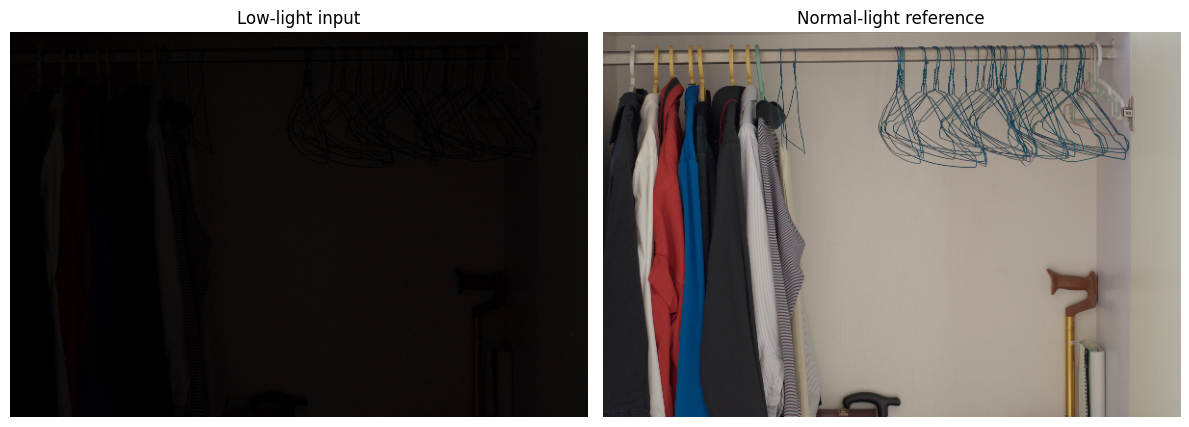

In [9]:
# Inspect a deterministic training pair before creating the training pipeline.
preview_pair = train_pairs[0]
preview_low = decode_rgb(tf.constant(preview_pair.low_path))
preview_high = decode_rgb(tf.constant(preview_pair.high_path))

print(f"Source: {preview_pair.source}")
print(f"Low-light shape: {preview_low.shape}; mean brightness: {tf.reduce_mean(preview_low).numpy():.3f}")
print(f"Reference shape: {preview_high.shape}; mean brightness: {tf.reduce_mean(preview_high).numpy():.3f}")
print(f"Low-light range: [{tf.reduce_min(preview_low).numpy():.3f}, {tf.reduce_max(preview_low).numpy():.3f}]")

figure, axes = plt.subplots(1, 2, figsize=(12, 5))
for axis, image, title in zip(axes, [preview_low, preview_high], ["Low-light input", "Normal-light reference"]):
    axis.imshow(image)
    axis.set_title(title)
    axis.axis("off")
figure.tight_layout()
plt.show()


In [10]:
def augment_pair(low: tf.Tensor, high: tf.Tensor) -> tuple[tf.Tensor, tf.Tensor]:
    # Stack first so every geometric operation affects both paired images identically.
    pair = tf.stack((resize_with_padding(low, CFG.resize_size), resize_with_padding(high, CFG.resize_size)))

    # Use scalar random decisions; batch-level random flip helpers can desynchronise a pair.
    if tf.random.uniform((), seed=CFG.seed) > 0.5:
        pair = tf.reverse(pair, axis=[2])  # Horizontal flip.
    if tf.random.uniform((), seed=CFG.seed) > 0.5:
        pair = tf.reverse(pair, axis=[1])  # Vertical flip.
    pair = tf.image.rot90(pair, tf.random.uniform((), 0, 4, tf.int32, seed=CFG.seed))
    pair = tf.image.random_crop(pair, (2, CFG.image_size, CFG.image_size, 3), seed=CFG.seed)

    # Light colour changes model sensor/exposure variation; keep the reference unchanged.
    low = tf.image.random_brightness(pair[0], max_delta=0.10, seed=CFG.seed)
    low = tf.image.random_contrast(low, 0.90, 1.10, seed=CFG.seed)
    return tf.clip_by_value(low, 0.0, 1.0), pair[1]


def prepare_evaluation_pair(low: tf.Tensor, high: tf.Tensor) -> tuple[tf.Tensor, tf.Tensor]:
    return resize_with_padding(low, CFG.image_size), resize_with_padding(high, CFG.image_size)


In [11]:
def make_dataset(pairs: list[ImagePair], training: bool = False) -> tf.data.Dataset:
    # Keep this small helper: it guarantees identical batching and prefetching in every split.
    if not pairs:
        raise ValueError("Cannot create a dataset from an empty list of pairs.")

    low_paths = [pair.low_path for pair in pairs]
    high_paths = [pair.high_path for pair in pairs]
    dataset = tf.data.Dataset.from_tensor_slices((low_paths, high_paths))
    if training:
        dataset = dataset.shuffle(len(pairs), seed=CFG.seed, reshuffle_each_iteration=True)

    dataset = dataset.map(decode_pair, num_parallel_calls=AUTOTUNE)
    transform = augment_pair if training else prepare_evaluation_pair
    dataset = dataset.map(transform, num_parallel_calls=AUTOTUNE)
    return dataset.batch(CFG.batch_size, drop_remainder=False).prefetch(AUTOTUNE)


train_ds = make_dataset(train_pairs, training=True)
validation_ds = make_dataset(validation_pairs)
test_ds = make_dataset(test_pairs)
low_batch, high_batch = next(iter(train_ds.take(1)))
print("Batch shapes:", low_batch.shape, high_batch.shape)


Batch shapes: (4, 384, 384, 3) (4, 384, 384, 3)


## 3. Define the attention U-Net

The model predicts the final RGB image directly. A single sigmoid keeps outputs in `[0, 1]`
without a second residual-add-and-clip stage that can saturate highlights.


In [12]:
def channel_attention(inputs: tf.Tensor, ratio: int = 8) -> tf.Tensor:
    channels = int(inputs.shape[-1])
    hidden_channels = max(channels // ratio, 1)
    reduce = layers.Dense(hidden_channels, activation="relu", kernel_initializer="he_normal")
    expand = layers.Dense(channels, kernel_initializer="he_normal")

    average = layers.Reshape((1, 1, channels))(layers.GlobalAveragePooling2D()(inputs))
    maximum = layers.Reshape((1, 1, channels))(layers.GlobalMaxPooling2D()(inputs))
    weights = layers.Activation("sigmoid")(layers.Add()([expand(reduce(average)), expand(reduce(maximum))]))
    return layers.Multiply()([inputs, weights])


def spatial_attention(inputs: tf.Tensor) -> tf.Tensor:
    average = layers.Lambda(lambda x: tf.reduce_mean(x, axis=-1, keepdims=True))(inputs)
    maximum = layers.Lambda(lambda x: tf.reduce_max(x, axis=-1, keepdims=True))(inputs)
    weights = layers.Conv2D(1, 7, padding="same", activation="sigmoid")(layers.Concatenate()([average, maximum]))
    return layers.Multiply()([inputs, weights])


In [13]:
def residual_block(inputs: tf.Tensor, filters: int) -> tf.Tensor:
    # Match the shortcut channel count only when necessary.
    shortcut = inputs if inputs.shape[-1] == filters else layers.Conv2D(filters, 1, padding="same")(inputs)
    x = layers.Conv2D(filters, 3, padding="same", use_bias=False)(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)
    x = layers.Conv2D(filters, 3, padding="same", use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = spatial_attention(channel_attention(x))
    return layers.Activation("relu")(layers.Add()([x, shortcut]))


def attention_gate(skip: tf.Tensor, decoder: tf.Tensor, filters: int) -> tf.Tensor:
    # Encoder and decoder tensors have matching sizes due to symmetric pooling/upsampling.
    skip_features = layers.Conv2D(filters, 1, padding="same")(skip)
    decoder_features = layers.Conv2D(filters, 1, padding="same")(decoder)
    weights = layers.Activation("sigmoid")(layers.Conv2D(1, 1, padding="same")(layers.Activation("relu")(layers.Add()([skip_features, decoder_features]))))
    return layers.Multiply()([skip, weights])


def upsample(inputs: tf.Tensor, filters: int) -> tf.Tensor:
    x = layers.UpSampling2D(2, interpolation="bilinear")(inputs)
    return layers.Conv2D(filters, 3, padding="same", activation="relu")(x)


In [14]:
def build_attention_unet(input_shape: tuple[int, int, int], base_filters: int) -> keras.Model:
    inputs = keras.Input(shape=input_shape, name="low_light_image")

    # Encoder: each stage halves resolution and doubles channel capacity.
    enc1 = residual_block(inputs, base_filters)
    enc2 = residual_block(layers.MaxPooling2D(2)(enc1), base_filters * 2)
    enc3 = residual_block(layers.MaxPooling2D(2)(enc2), base_filters * 4)
    enc4 = residual_block(layers.MaxPooling2D(2)(enc3), base_filters * 8)
    bottleneck = residual_block(layers.MaxPooling2D(2)(enc4), base_filters * 16)

    # Decoder: attention gates select useful encoder detail before concatenation.
    up4 = upsample(bottleneck, base_filters * 8)
    dec4 = residual_block(layers.Concatenate()([up4, attention_gate(enc4, up4, base_filters * 4)]), base_filters * 8)
    up3 = upsample(dec4, base_filters * 4)
    dec3 = residual_block(layers.Concatenate()([up3, attention_gate(enc3, up3, base_filters * 2)]), base_filters * 4)
    up2 = upsample(dec3, base_filters * 2)
    dec2 = residual_block(layers.Concatenate()([up2, attention_gate(enc2, up2, base_filters)]), base_filters * 2)
    up1 = upsample(dec2, base_filters)
    dec1 = residual_block(layers.Concatenate()([up1, attention_gate(enc1, up1, max(base_filters // 2, 1))]), base_filters)

    outputs = layers.Conv2D(3, 1, activation="sigmoid", name="enhanced_image")(dec1)
    return keras.Model(inputs, outputs, name="attention_unet_low_light")


In [15]:
def ssim_loss(y_true: tf.Tensor, y_pred: tf.Tensor) -> tf.Tensor:
    return 1.0 - tf.reduce_mean(tf.image.ssim(y_true, y_pred, max_val=1.0))


def combined_loss(y_true: tf.Tensor, y_pred: tf.Tensor) -> tf.Tensor:
    # MAE preserves pixel accuracy; SSIM favours structural similarity.
    mae = tf.reduce_mean(tf.abs(y_true - y_pred))
    return 0.4 * mae + 0.6 * ssim_loss(y_true, y_pred)


def psnr_metric(y_true: tf.Tensor, y_pred: tf.Tensor) -> tf.Tensor:
    return tf.reduce_mean(tf.image.psnr(y_true, y_pred, max_val=1.0))


def ssim_metric(y_true: tf.Tensor, y_pred: tf.Tensor) -> tf.Tensor:
    return tf.reduce_mean(tf.image.ssim(y_true, y_pred, max_val=1.0))


In [16]:
model = build_attention_unet((CFG.image_size, CFG.image_size, 3), CFG.base_filters)
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=CFG.learning_rate),
    loss=combined_loss,
    metrics=[psnr_metric, ssim_metric],
)
model.summary()


Model: "attention_unet_low_light"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ low_light_image     │ (None, 384, 384,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 384, 384,  │      1,296 │ low_light_image[… │
│                     │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 384, 384,  │        192 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 384, 384,  │          0 │ batch_normalizat… │
│ (Activation)        │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 384, 384,  │     20,736 │ activation[0][0]  │
│                     │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 384, 384,  │        192 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 48)        │          0 │ batch_normalizat… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_max_pooling… │ (None, 48)        │          0 │ batch_normalizat… │
│ (GlobalMaxPooling2… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape (Reshape)   │ (None, 1, 1, 48)  │          0 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape_1 (Reshape) │ (None, 1, 1, 48)  │          0 │ global_max_pooli… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 1, 1, 6)   │        294 │ reshape[0][0],    │
│                     │                   │            │ reshape_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 1, 1, 48)  │        336 │ dense[0][0],      │
│                     │                   │            │ dense[1][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 1, 1, 48)  │          0 │ dense_1[0][0],    │
│                     │                   │            │ dense_1[1][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 1, 1, 48)  │          0 │ add[0][0]         │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply (Multiply) │ (None, 384, 384,  │          0 │ batch_normalizat… │
│                     │ 48)               │            │ activation_1[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda (Lambda)     │ (None, 384, 384,  │          0 │ multiply[0][0]    │
│                     │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_1 (Lambda)   │ (None, 384, 384,  │          0 │ multiply[0][0]    │
│                     │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 20,660,110 (78.81 MB)

 Trainable params: 20,651,278 (78.78 MB)

 Non-trainable params: 8,832 (34.50 KB)

## 4. Train and save artifacts


In [17]:
best_model_path = OUTPUT_DIR / "best_low_light_model.keras"

callbacks = [
    # Persist only the model with the best validation PSNR.
    keras.callbacks.ModelCheckpoint(best_model_path, monitor="val_psnr_metric", mode="max", save_best_only=True, verbose=1),
    keras.callbacks.EarlyStopping(monitor="val_psnr_metric", mode="max", patience=12, restore_best_weights=True, verbose=1),
    keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=4, min_lr=1e-6, verbose=1),
    keras.callbacks.CSVLogger(OUTPUT_DIR / "training_log.csv"),
    keras.callbacks.TerminateOnNaN(),
]


In [18]:
history = model.fit(train_ds, validation_data=validation_ds, epochs=CFG.epochs, callbacks=callbacks)

# Save the restored best weights and the exact run configuration.
model.save(best_model_path)
(OUTPUT_DIR / "training_config.json").write_text(json.dumps(asdict(CFG), indent=2))


Epoch 1/80
467/467 ━━━━━━━━━━━━━━━━━━━━ 0s 887ms/step - loss: 0.3060 - psnr_metric: 14.6590 - ssim_metric: 0.6060
Epoch 1: val_psnr_metric improved from None to 17.66213, saving model to /kaggle/working/denoisex/best_low_light_model.keras

Epoch 1: finished saving model to /kaggle/working/denoisex/best_low_light_model.keras
467/467 ━━━━━━━━━━━━━━━━━━━━ 457s 921ms/step - loss: 0.2650 - psnr_metric: 15.8301 - ssim_metric: 0.6568 - val_loss: 0.1944 - val_psnr_metric: 17.6621 - val_ssim_metric: 0.7532 - learning_rate: 0.0010
Epoch 2/80
467/467 ━━━━━━━━━━━━━━━━━━━━ 0s 899ms/step - loss: 0.2149 - psnr_metric: 17.1418 - ssim_metric: 0.7227
Epoch 2: val_psnr_metric improved from 17.66213 to 19.28325, saving model to /kaggle/working/denoisex/best_low_light_model.keras

Epoch 2: finished saving model to /kaggle/working/denoisex/best_low_light_model.keras
467/467 ━━━━━━━━━━━━━━━━━━━━ 434s 929ms/step - loss: 0.2041 - psnr_metric: 17.3543 - ssim_metric: 0.7382 - val_loss: 0.1491 - val_psnr_metric: 

248

## 5. Evaluate only on held-out data


In [19]:
# Evaluate the complete held-out set and each dataset source separately.
results = []
evaluation_sets = {"all-held-out": test_pairs, **{source: [pair for pair in test_pairs if pair.source == source] for source in count_sources(test_pairs)}}

for name, pairs in evaluation_sets.items():
    metrics = model.evaluate(make_dataset(pairs), return_dict=True, verbose=0)
    result = {"dataset": name, "pairs": len(pairs), **{key: float(value) for key, value in metrics.items()}}
    results.append(result)
    print(result)

(OUTPUT_DIR / "test_metrics.json").write_text(json.dumps(results, indent=2))


{'dataset': 'all-held-out', 'pairs': 215, 'loss': 0.07901646941900253, 'psnr_metric': 23.265592575073242, 'ssim_metric': 0.9095165133476257}
{'dataset': 'LOL', 'pairs': 15, 'loss': 0.0871497318148613, 'psnr_metric': 22.2720947265625, 'ssim_metric': 0.894758939743042}
{'dataset': 'LOL-v2-real', 'pairs': 100, 'loss': 0.06160483509302139, 'psnr_metric': 24.7235164642334, 'ssim_metric': 0.9295132160186768}
{'dataset': 'LOL-v2-synthetic', 'pairs': 100, 'loss': 0.09520810842514038, 'psnr_metric': 21.955249786376953, 'ssim_metric': 0.8916773796081543}


661

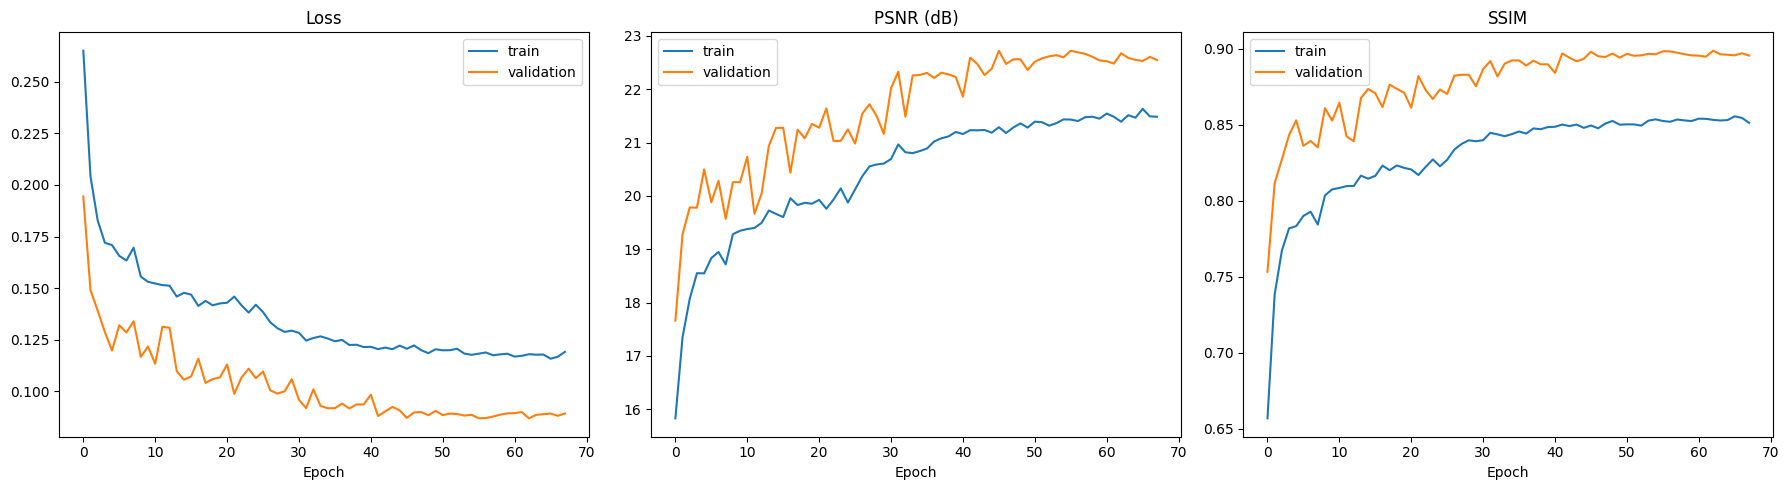

In [20]:
# Plot training/validation curves for the three metrics tracked by `model.fit`.
charts = [("loss", "Loss"), ("psnr_metric", "PSNR (dB)"), ("ssim_metric", "SSIM")]
figure, axes = plt.subplots(1, len(charts), figsize=(18, 5))
for axis, (key, title) in zip(axes, charts):
    axis.plot(history.history[key], label="train")
    axis.plot(history.history[f"val_{key}"], label="validation")
    axis.set(title=title, xlabel="Epoch")
    axis.legend()
figure.tight_layout()
figure.savefig(OUTPUT_DIR / "training_history.png", dpi=160)
plt.show()


2026-07-29 05:47:38.610775: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


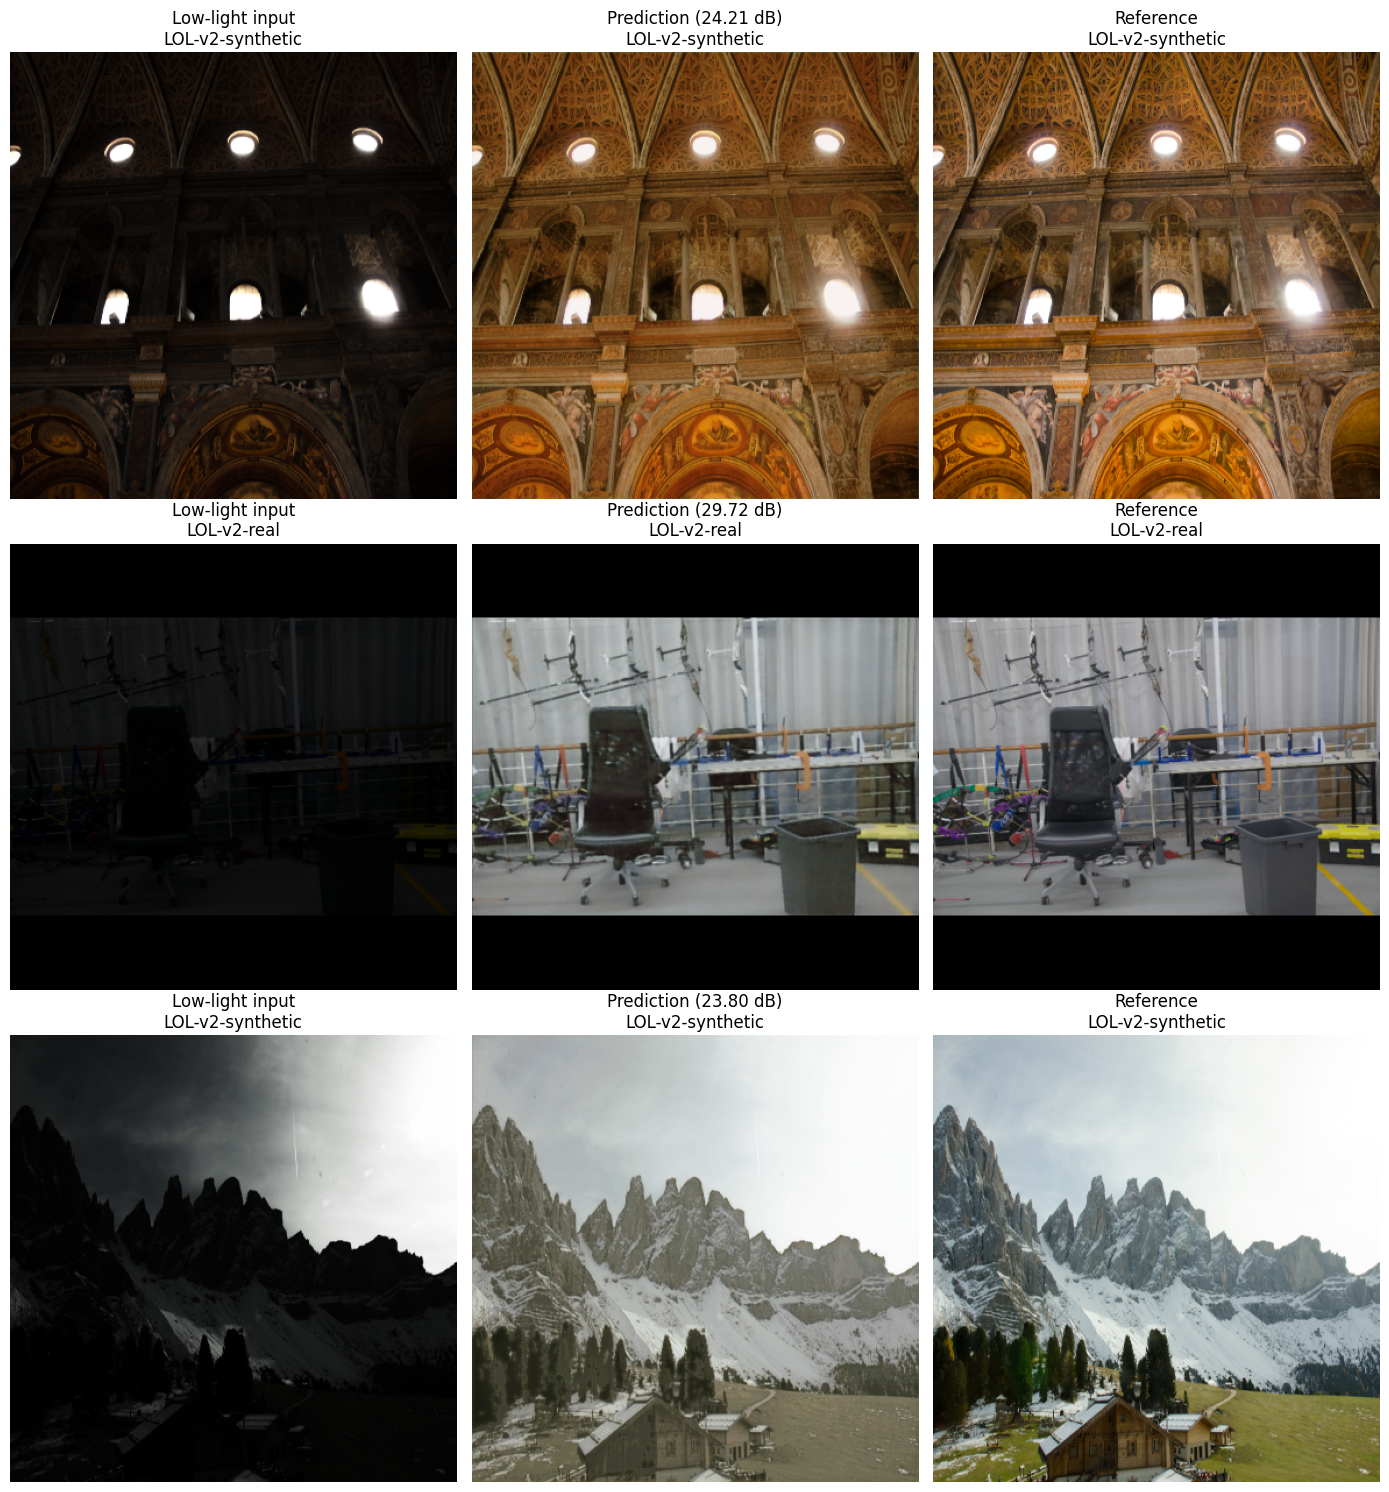

In [21]:
# Inspect a deterministic sample of held-out predictions.
sample_count = min(3, len(test_pairs))
selected_indices = np.random.default_rng(CFG.seed).choice(len(test_pairs), sample_count, replace=False)
selected_pairs = [test_pairs[index] for index in selected_indices]
low_images, high_images = next(iter(make_dataset(selected_pairs).unbatch().batch(sample_count)))
predictions = model.predict(low_images, verbose=0)

figure, axes = plt.subplots(sample_count, 3, figsize=(14, 5 * sample_count), squeeze=False)
for row, pair in enumerate(selected_pairs):
    psnr = float(tf.image.psnr(high_images[row], predictions[row], max_val=1.0))
    for axis, image, title in zip(axes[row], [low_images[row], predictions[row], high_images[row]], ["Low-light input", f"Prediction ({psnr:.2f} dB)", "Reference"]):
        axis.imshow(image)
        axis.set_title(f"{title}\n{pair.source}")
        axis.axis("off")
figure.tight_layout()
figure.savefig(OUTPUT_DIR / "held_out_predictions.png", dpi=160)
plt.show()
